In [1]:
#!pip install pypsa

In [2]:
# Needed imports 
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Path extention
sys.path.append('../src')
sys.path.append('../data')
sys.path.append('../data/Prices')

# Functions import
from Load_Data import load_parquet, construct_dataframe, read_csv
from Plot_Functions import plot_timeseries, compute_market_price_by_country#, create_simple_network
from cost_dict import cost_dict  # as to be a cost_dict.py files

### Loading data

In [3]:
dict_ISOCODE={'AT': 'AUT', 'BE': 'BEL', 'BG': 'BGR', 'CH': 'CHE', 'CY': 'CYP',
              'CZ': 'CZE', 'DE': 'DEU', 'DK': 'DNK', 'ES': 'ESP', 'FI': 'FIN',
              'FR': 'FRA', 'GB': 'GBR', 'GR': 'GRC', 'HR': 'HRV', 'HU': 'HUN',
              'IE': 'IRL', 'IT': 'ITA', 'LT': 'LTU', 'LU': 'LUX', 'LV': 'LVA',
              'MT': 'MLT', 'NL': 'NLD', 'NO': 'NOR', 'PL': 'POL', 'PT': 'PRT',
              'RO': 'ROU', 'SE': 'SWE', 'SI': 'SVN', 'SK': 'SVK'}

inv_isocode={v: k for k, v in dict_ISOCODE.items()}

In [4]:
data_dir = Path("../data")
df_dom = pd.read_csv(data_dir / "monthly_domestic_values_2024.csv", sep="\t")
pivot_dom_table = df_dom.pivot_table(index="Month",columns={"Category","Area"}, values="ProvidedValue")
df_load = pd.read_csv(data_dir / "monthly_hourly_load_values_2024.csv", sep="\t")
pivot_load_table = df_load.pivot_table(index="DateUTC",columns="CountryCode", values="Value")
df_pf = pd.read_csv(data_dir / "physical_energy_power_flows_2024.csv", sep=";")
monthly_pf_table = df_pf.pivot_table(index="Month",columns={"FromAreaCode","ToAreaCode"}, values="ProvidedValue")
# print(pivot_load_table['FR'])

In [5]:
import re

def load_prices(d_min = "2024-01-01 00:00:00", d_max = "2024-12-31 23:59:59")-> pd.DataFrame:
    """Load electricity prices from CSV file and return a pivot table.
        d_min (str): Start date for filtering data (inclusive).
        d_max (str): End date for filtering data (inclusive).
    
    Returns:
        pd.DataFrame: Pivot table with Datetime (UTC) as index, ISO3 Code as columns, and Price (EUR/MWhe) as values.
    """
    df_prices = pd.read_csv(data_dir /"Prices"/ "all_countries.csv", sep=",")
    df_prices["Datetime (UTC)"] = pd.to_datetime(df_prices["Datetime (UTC)"])
    df_prices = df_prices.rename(columns={"Datetime (UTC)": "DateTime"})
    mask = (df_prices["DateTime"] >= d_min) & (df_prices["DateTime"] <= d_max)
    df_filtered = df_prices.loc[mask]
    pivot_price_table = df_filtered.pivot_table(index="DateTime",columns="ISO3 Code", values="Price (EUR/MWhe)")
    pivot_price_table = pivot_price_table.dropna()
    pivot_price_table = pivot_price_table.rename(columns=replace_iso3_in_col)
    pivot_price_table = pivot_price_table.rename(lambda c: f"Price_{c}" if c != "DateTime" else c, axis=1)
    return pivot_price_table
    
def replace_iso3_in_col(col_name: str) -> str:
    if col_name == "DateTime":
        return col_name
    new = col_name
    # remplace chaque ISO3 s'il apparaît en tant que token (borne par word boundaries)
    for iso3, two in inv_isocode.items():
        new = re.sub(rf"\b{re.escape(iso3)}\b", two, new)
    return new

In [6]:
def extract_country_dom(pivot_dom_table: pd.DataFrame, country: str) -> pd.DataFrame:
    """
    Extrait les données de production domestique (par catégorie) pour un pays donné.

    Args:
        pivot_dom_table : DataFrame avec colonnes MultiIndex (Category, Area)
        country : code du pays à extraire (ex: "FR", "DE", "ES")
        drop_constant : si True, supprime aussi les colonnes dont toutes les valeurs
                        non-NaN sont identiques (variance nulle).

    Returns:
        DataFrame avec index = Month et colonnes = catégories énergétiques suffixées par _{country}
    """
    if not isinstance(pivot_dom_table.columns, pd.MultiIndex):
        raise ValueError("Le pivot_dom_table doit avoir un MultiIndex (Category, Area).")

    # Filtrer les colonnes correspondant au pays
    # On garde uniquement les colonnes où le niveau 'Area' == country
    # pivot_dom_table.columns est du type MultiIndex[(Category, Area), ...]
    df_country = pivot_dom_table.loc[:, pivot_dom_table.columns.get_level_values(1) == country].copy()

    if df_country.shape[1] == 0:
        # Pas de colonnes pour ce pays
        return pd.DataFrame(index=pivot_dom_table.index)

    # Maintenant renommer à partir des colonnes restantes réelles (évite le décalage)
    # Chaque col est un tuple (Category, Area)
    new_cols = []
    for col in df_country.columns:
        if isinstance(col, tuple) and len(col) >= 2:
            category = col[0]
        else:
            # au cas où ce n'est pas un tuple (defensive)
            category = str(col)
        new_cols.append(f"{category}_{country}")

    df_country.columns = new_cols

    # (Optionnel) tri alphabétique des colonnes pour lisibilité
    df_country = df_country.reindex(sorted(df_country.columns), axis=1)
    
    # Supprimer les colonnes entièrement NaN
    df_country = df_country.dropna(axis=1, how='any')

    return df_country


In [7]:
def build_hourly_dataframe(countries, pivot_load_table, pivot_pf_table, pivot_dom_table):
    """
    Construit un DataFrame horaire complet pour une liste de pays donnée,
    à partir de tables de production/domestique (mensuelle) et de charge (horaire).
    
    Paramètres :
    ------------
    countries : list[str]
        Liste des pays à inclure (ex: ['FR', 'DE', 'ES'])
    pivot_load_table : pd.DataFrame
        DataFrame des load 
    pivot_pf_table : pd.DataFrame
        DataFrame des power flow 
    pivot_dom_table : pd.DataFrame
        DataFrame des dom 
    
    Retour :
    --------
    pd.DataFrame
        DataFrame horaire complet sur la période commune à toutes les sources
    """
    
    # # Vérifier que les index sont bien datetime
    if not pd.api.types.is_datetime64_any_dtype(df_dom.index):
        df_dom.index = pd.to_datetime(df_dom.index)
    if not pd.api.types.is_datetime64_any_dtype(pivot_load_table.index):
        pivot_load_table.index = pd.to_datetime(pivot_load_table.index, format="%d-%m-%Y %H:%M")
    if pivot_pf_table is not None and not pd.api.types.is_datetime64_any_dtype(df_pf.index):
        df_pf.index = pd.to_datetime(df_pf.index)
    
    # Déterminer la période temporelle totale
    t_min = pivot_load_table.index.min()
    t_max = pivot_load_table.index.max()
    
    # Créer l’index horaire complet
    datetime_index = pd.date_range(start=t_min, end=t_max, freq='h')
    df_final = pd.DataFrame({'datetime': datetime_index})
    df_final.set_index('datetime', inplace=True)
    
    # Boucle sur chaque pays
    for country in countries:
        # Récupérer les colonnes du pays dans chaque table
        col_dom = extract_country_dom(pivot_dom_table, country) if pivot_dom_table is not None else None
        col_load = pivot_load_table[country] if country in pivot_load_table.columns else None
        col_flow = pivot_pf_table[country] if (pivot_pf_table is not None and country in pivot_pf_table.columns) else None
        df_temp = pd.DataFrame({'datetime': datetime_index})
        df_temp.set_index('datetime', inplace=True)
        # Étendre la donnée mensuelle à chaque heure du mois
        if col_dom is not None:
            # col_dom : DataFrame indexé par Month (1..12), colonnes = catégories (ex: 'Wind_FR')
            # On crée une série horaire pour chaque catégorie et on l'ajoute à df_temp
            for col in col_dom.columns:
                monthly_series = col_dom[col].astype(float)  # Series indexée par mois
                hourly = pd.Series(index=datetime_index, dtype=float)
                for month, value in monthly_series.items():
                    # s'assurer que month est un int (1..12)
                    m = int(month)
                    mask = hourly.index.month == m
                    hourly.loc[mask] = value
                # nettoyer le nom de colonne (retirer suffixe _{country} si présent)
                cat = col.replace(f"_{country}", "") if isinstance(col, str) else str(col)
                df_temp[f"{cat}_gen_{country}"] = hourly.values
            # Si tu veux une seule colonne dom agrégée (somme de catégories), décommente :
            # df_temp[f"{country}_dom"] = df_temp[[c for c in df_temp.columns if c.endswith(f'_{country}_dom')]].sum(axis=1)
        else:
             df_final[f"{country}_dom"] = None

        # Ajouter les données horaires
        if col_load is not None:
            df_temp[f'{country}_load'] = col_load
            # df_final[f"{country}_load"] = col_load.reindex(datetime_index, method='nearest')
        else:
            df_final[f"{country}_load"] = None
        
        if pivot_pf_table is not None:
            # Filtrer les colonnes correspondant au pays source
            country_cols = [col for col in pivot_pf_table.columns if col[0] == country]

            if country_cols:
                df_pf_temp = pd.DataFrame({'datetime': datetime_index})

                for (from_area, to_area) in country_cols:
                    col_name = f"From_{from_area}_to_{to_area}"
                    monthly_series = pivot_pf_table[(from_area, to_area)]

                    # Étendre les valeurs mensuelles sur toutes les heures du mois
                    df_pf_hourly = pd.Series(index=datetime_index, dtype=float)
                    for month, value in monthly_series.items():
                        mask = df_pf_hourly.index.month == month
                        df_pf_hourly.loc[mask] = value

                    df_pf_temp[col_name] = df_pf_hourly.values

                # Fusionner avec le df_final
                df_final = pd.merge(df_final, df_pf_temp, on='datetime', how='left')
        df_final = pd.merge(df_final, df_temp, on='datetime', how='left')
        df_final = df_final.rename(columns={"datetime":"DateTime"})
        df_final['DateTime'] = pd.to_datetime(df_final['DateTime'])
        df_final = df_final.set_index('DateTime')

    return df_final


### Creation of a cost function, estimating electricity price using the SPOT market, returning the dataframe with the estimated price and the source of the last technology called

In [8]:
# !pip install xgboost

In [9]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error
import xgboost as xgb

In [10]:
def add_temporal_features(df: pd.DataFrame) -> pd.DataFrame:
    """Ajoute des features temporelles au DataFrame."""
    df = df.copy()
    # Convertir DateTime en datetime si ce n'est pas déjà fait
    if not pd.api.types.is_datetime64_any_dtype(df['DateTime']):
        df['DateTime'] = pd.to_datetime(df['DateTime'])
    
    # Features temporelles basiques
    df['hour'] = df['DateTime'].dt.hour
    df['day'] = df['DateTime'].dt.day
    df['month'] = df['DateTime'].dt.month
    df['day_of_week'] = df['DateTime'].dt.dayofweek
    
    # Features cycliques pour capturer la périodicité
    df['hour_sin'] = np.sin(2 * np.pi * df['hour']/24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour']/24)
    df['month_sin'] = np.sin(2 * np.pi * df['month']/12)
    df['month_cos'] = np.cos(2 * np.pi * df['month']/12)
    
    return df

def calculate_net_exchanges(df: pd.DataFrame, country: str) -> pd.Series:
    """Calcule les échanges nets pour un pays (exports - imports)."""
    # Trouver toutes les colonnes d'échange impliquant ce pays
    exchange_cols = [col for col in df.columns if 'From_' in col and '_to_' in col]
    
    net_exchange = pd.Series(0, index=df.index)
    for col in exchange_cols:
        from_country, to_country = col.split('From_')[1].split('_to_')
        if from_country == country:
            # Export: valeur positive
            net_exchange += df[col]
        elif to_country == country:
            # Import: valeur négative
            net_exchange -= df[col]
            
    return net_exchange

def build_feature_target_df(df_features: pd.DataFrame, df_price: pd.DataFrame,
                            country_code: str, target_col: str = 'Price') -> pd.DataFrame:
    """
    df_features : DataFrame index horaire avec toutes les variables explicatives (ex: load, gen, flux…)
    df_price : DataFrame index horaire avec prix jour-avant pour le pays
    country_code : code pays pour lequel on prédit
    target_col : nom de la colonne prix dans df_price
    """
    df = df_features.copy()
    # Assumer que df_price a une colonne nommée e.g. '{country_code}_price'
    df_target = df_price[[f"{target_col}_{country_code}"]].rename(columns={f"{target_col}_{country_code}": 'y'})
    df = df.join(df_target, how='inner')
    df = df.dropna(subset=['y'])
    return df

def build_features_for_price_prediction(df: pd.DataFrame, target_country: str) -> pd.DataFrame:
    """Construit le dataset complet pour la prédiction des prix."""
    features_df = df.copy()
    
    # 1. Ajouter features temporelles
    features_df = add_temporal_features(features_df)
    
    # 2. Calculer échanges nets
    features_df[f'net_exchanges_{target_country}'] = calculate_net_exchanges(df, target_country)
    
    # 3. Sélectionner les features pertinentes
    relevant_features = [
        # Features temporelles
        'hour', 'day', 'month', 'day_of_week',
        'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
        
        # Load du pays cible
        f'{target_country}_load',
        
        # Production par type (colonnes se terminant par f"_gen_{target_country}")
        *[col for col in features_df.columns if col.endswith(f'_gen_{target_country}')],
        
        # Échanges nets
        f'net_exchanges_{target_country}'
    ]
    
    return features_df[relevant_features]

def train_enhanced_price_model(df: pd.DataFrame, df_prices: pd.DataFrame, 
                             country_code: str, n_splits: int = 5):
    """
    Entraîne un modèle XGBoost amélioré pour la prédiction des prix.
    
    Args:
        df: DataFrame avec toutes les données (load, production, échanges)
        df_prices: DataFrame avec les prix historiques
        country_code: code pays à prédire
        n_splits: nombre de splits pour la validation croisée
    """
    # 1. Construire features
    X = build_features_for_price_prediction(df, country_code)
    
    # 2. Préparer target
    y = df_prices[f'Price_{country_code}']
    
    # 3. Split train/test chronologique
    train_size = int(len(X) * 0.8)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]
    
    # 4. Pipeline avec preprocessing
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('xgb', xgb.XGBRegressor(
            objective='reg:squarederror',
            n_estimators=300,
            learning_rate=0.05,
            max_depth=5,
            random_state=42
        ))
    ])
    
    # 5. Entraînement
    pipeline.fit(X_train, y_train)
    
    # 6. Évaluation
    y_pred = pipeline.predict(X_test)
    print(f"Metrics for {country_code}:")
    print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
    
    return pipeline, X_test, y_test, y_pred

In [11]:
countries = ["FR"]
df_prices_2024 = load_prices(d_min="2024-01-01 00:00:00", d_max="2024-12-31 23:00:00")
df_features = build_hourly_dataframe(countries, pivot_load_table, monthly_pf_table, pivot_dom_table)
missing_hours = df_features.index.difference(df_prices_2024.index)
# print("\nHMissing hours:", len(missing_hours))
# print(missing_hours)


In [ ]:
# Align the dataframes
df_aligned = pd.merge(df_features, df_prices_2024, 
                     left_index=True, 
                     right_index=True, 
                     how='inner')

# Now both price and feature data will have the same number of rows
# print(df_aligned.head())

                     From_FR_to_BE  From_FR_to_CH  From_FR_to_DE  \
DateTime                                                           
2024-01-01 00:00:00         1017.5        1380.25         1686.0   
2024-01-01 01:00:00         1017.5        1380.25         1686.0   
2024-01-01 02:00:00         1017.5        1380.25         1686.0   
2024-01-01 03:00:00         1017.5        1380.25         1686.0   
2024-01-01 04:00:00         1017.5        1380.25         1686.0   

                     From_FR_to_ES  From_FR_to_GB  From_FR_to_IT  FR_load  \
DateTime                                                                    
2024-01-01 00:00:00        1518.25        1107.25         1811.5  52846.0   
2024-01-01 01:00:00        1518.25        1107.25         1811.5  51599.0   
2024-01-01 02:00:00        1518.25        1107.25         1811.5  50992.0   
2024-01-01 03:00:00        1518.25        1107.25         1811.5  48186.0   
2024-01-01 04:00:00        1518.25        1107.25         181

Metrics for FR:
MAE: 36.27
RMSE: 43.18


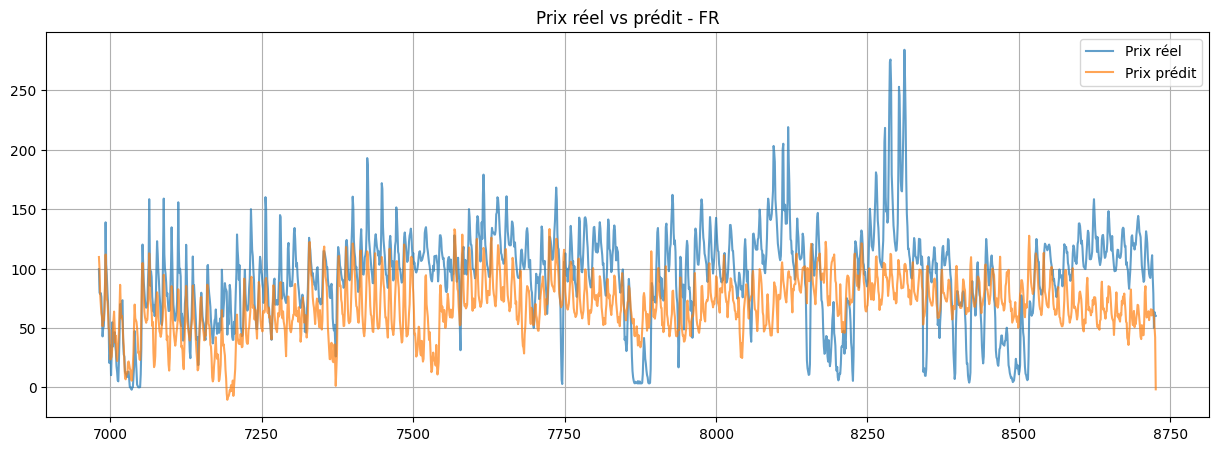


Top 10 features importantes:
            feature  importance
5          hour_cos    0.206727
8           FR_load    0.159833
4          hour_sin    0.110916
9  net_exchanges_FR    0.103586
2             month    0.097996
0              hour    0.094560
6         month_sin    0.071888
7         month_cos    0.064552
3       day_of_week    0.045204
1               day    0.044737


In [13]:
# Pour un pays
country = 'FR'

# Entraînement du modèle amélioré
model, X_test, y_test, y_pred = train_enhanced_price_model(
    df_aligned.reset_index(), 
    df_aligned[['Price_FR']],
    country_code=country
)

# Visualisation
plt.figure(figsize=(15, 5))
plt.plot(X_test.index, y_test, label='Prix réel', alpha=0.7)
plt.plot(X_test.index, y_pred, label='Prix prédit', alpha=0.7)
plt.title(f'Prix réel vs prédit - {country}')
plt.legend()
plt.grid(True)
plt.show()

# Feature importance
feature_importance = pd.DataFrame({
    'feature': X_test.columns,
    'importance': model.named_steps['xgb'].feature_importances_
}).sort_values('importance', ascending=False)
print("\nTop 10 features importantes:")
print(feature_importance.head(10))

Even if the model does not capture every 

### Pypsa Part

Avertissement : colonne Demand_ES manquante.
Avertissement : colonne Demand_DE manquante.


{'nodes': {'Bus': <matplotlib.collections.PatchCollection at 0x2b04601b460>},
 'branches': {'Link': <matplotlib.collections.LineCollection at 0x2b04605c0a0>},
 'flows': {}}

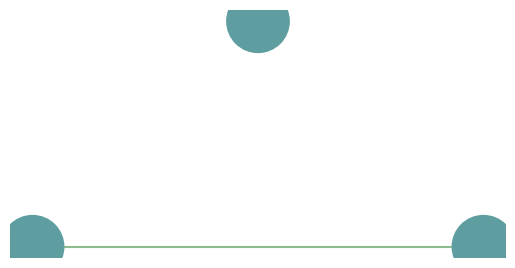

In [ ]:
# Liste de pays présent dans le réseau
countries = ['FR','ES','DE']

# Création du réseau
net = create_simple_network(df,countries, cost_dict)

# Affichage du réseau
net.plot.map()